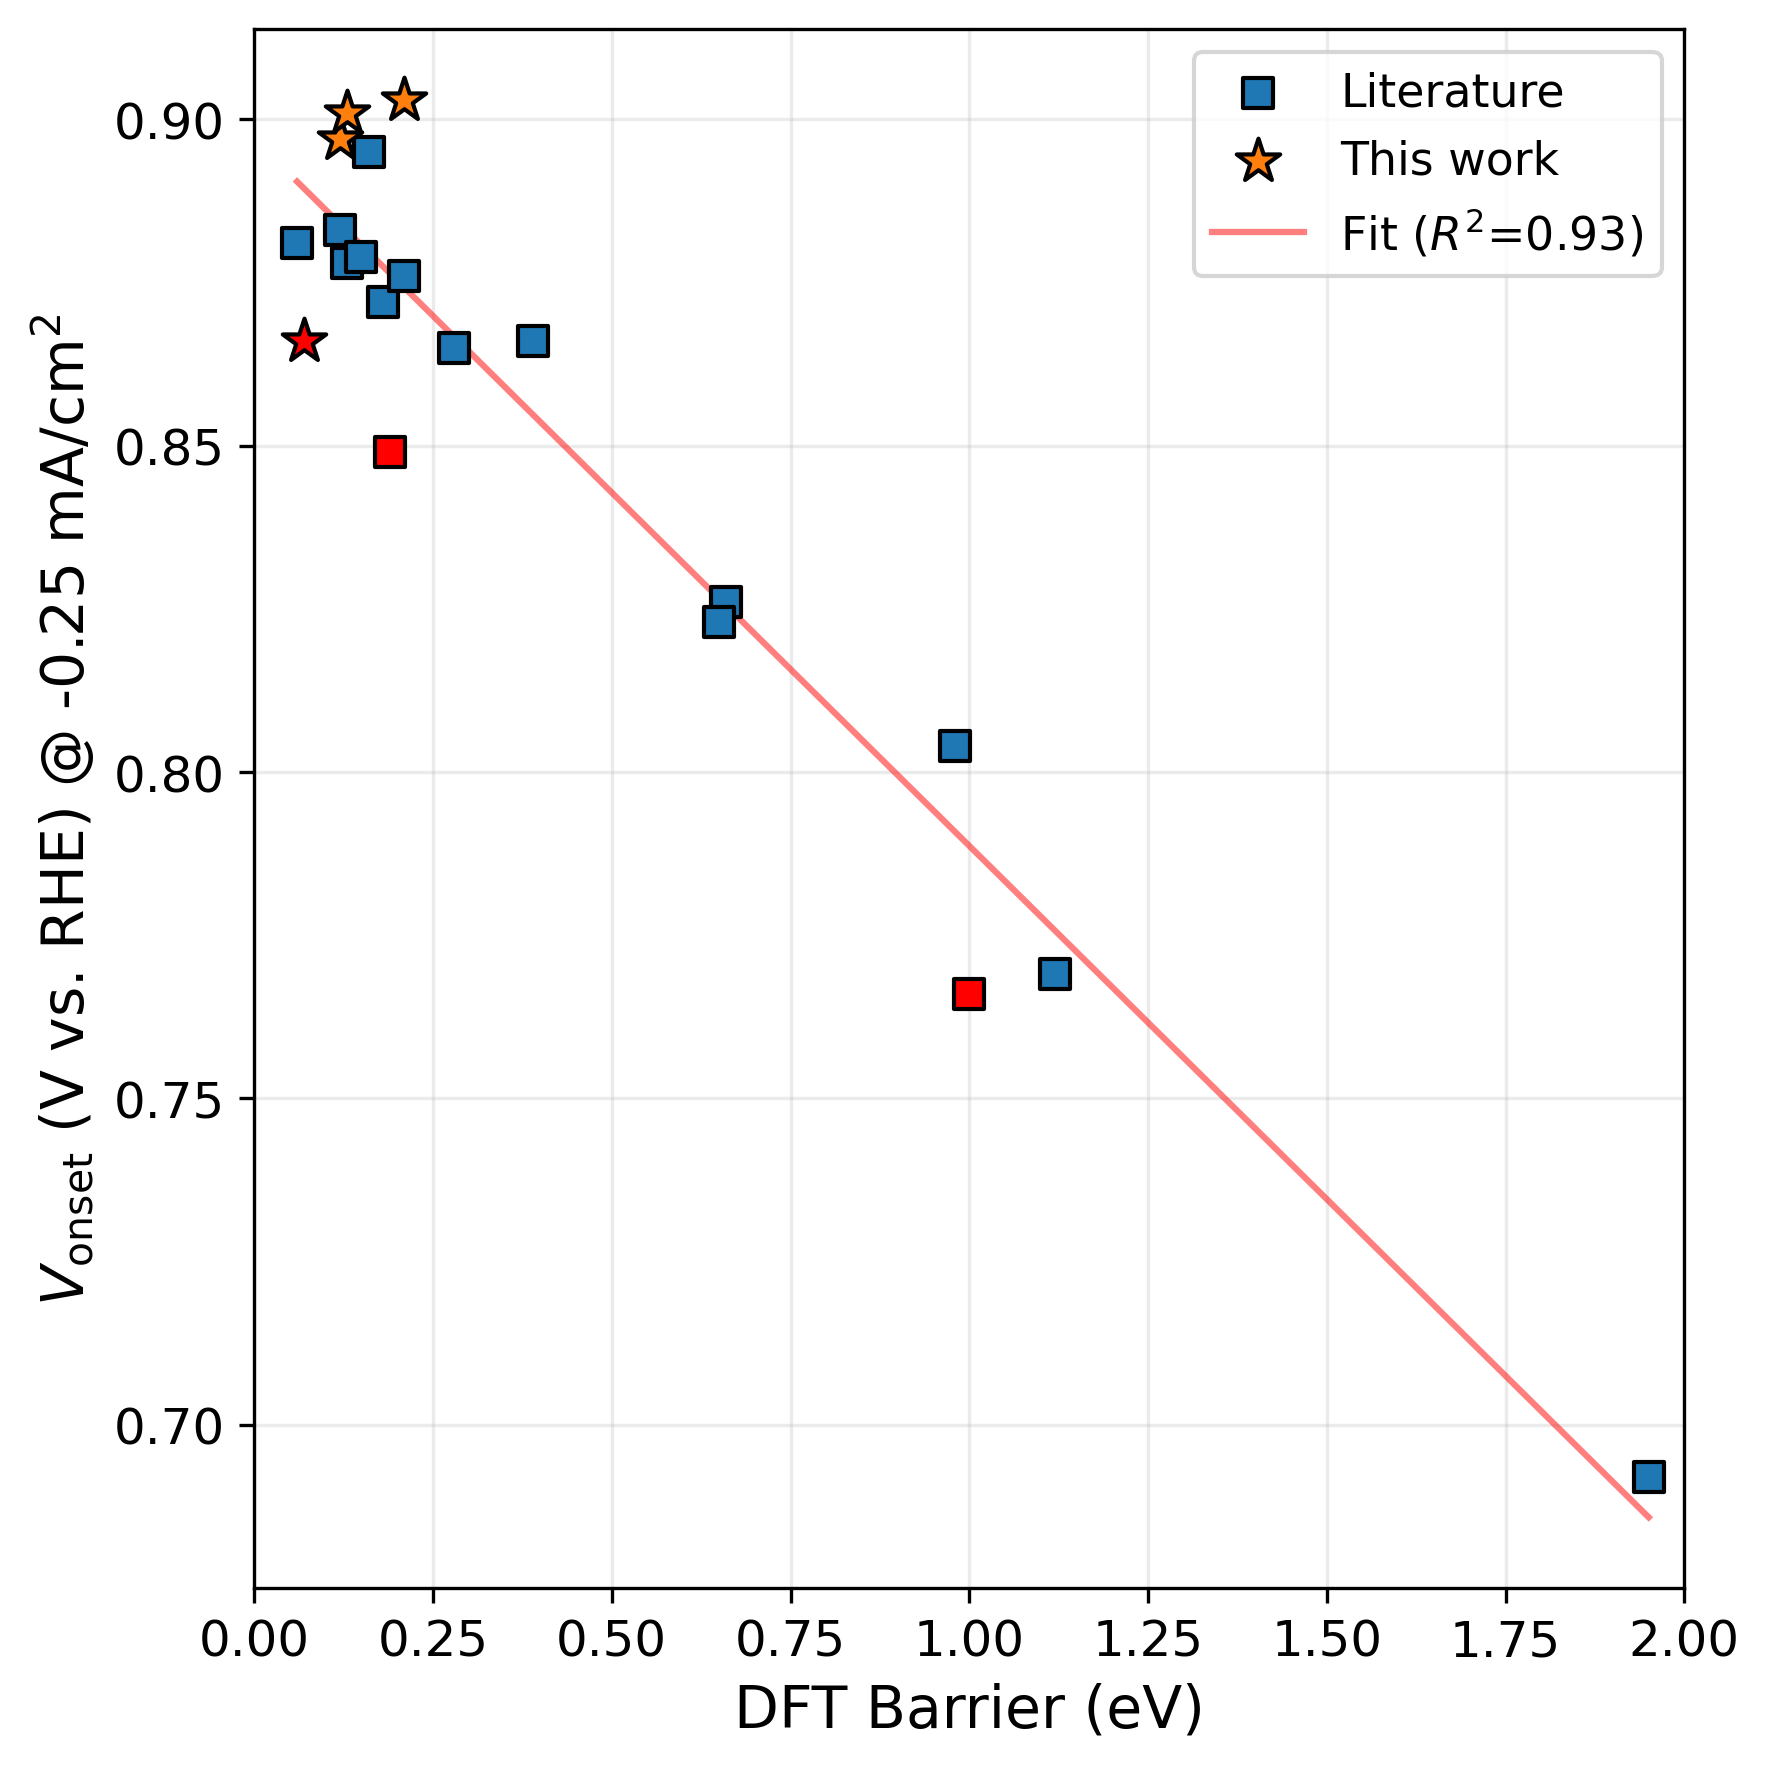

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ax_font_size = 14

def plot_dft_vs_vonset(
    literature_data,
    this_work_data,
    gap_threshold: float = 2.5,
) -> None:

    def unpack(arr):
        return (
            [r[0] for r in arr],
            np.array([r[1] for r in arr]),
            np.array([r[3] for r in arr]),
            np.array([r[4] for r in arr]),
        )

    ids_lit, barr_lit, von_lit, gap_lit = unpack(literature_data)
    ids_tw,  barr_tw,  von_tw,  gap_tw  = unpack(this_work_data)

    dft_lit = 1.24 - barr_lit
    dft_tw  = 1.24 - barr_tw

    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

    # helper plotting
    def plot_set(x, y, gaps, marker, default_color, label):
        label_used = False
        for xi, yi, gi in zip(x, y, gaps):
            face = 'red' if gi >= gap_threshold else default_color
            ax.scatter(xi, yi, marker=marker, edgecolors='black',
                       facecolors=face,
                       s=120 if marker == '*' else 50,
                       label=label if not label_used else None,
                       zorder=4)
            label_used = True

    plot_set(dft_lit, von_lit, gap_lit, 's', 'C0', 'Literature')
    plot_set(dft_tw,  von_tw,  gap_tw,  '*', 'C1', 'This work')

    # regression on all points
    all_x = np.concatenate([dft_lit, dft_tw])
    all_y = np.concatenate([von_lit, von_tw])
    m, b = np.polyfit(all_x, all_y, 1)
    r2 = np.corrcoef(all_x, all_y)[0, 1] ** 2
    xs = np.linspace(all_x.min(), all_x.max(), 100)
    ax.plot(xs, m*xs + b, color='red', alpha=0.5, label=f'Fit ($R^2$={r2:.2f})')

    ax.set_xlabel('DFT Barrier (eV)', fontsize=ax_font_size)
    ax.set_ylabel('$V_{\\mathrm{onset}}$ (V vs. RHE) @ -0.25 mA/cm$^2$', fontsize=ax_font_size)
    ax.set_xlim(0, 2)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=ax_font_size-3)
    ax.tick_params(labelsize=ax_font_size-2)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Literature (Name, DFT Onset V, Half wave, Onset V, Band gap)
    literature_data_points = [
        ("Co3",   0.96, 0.748, 0.865, 1.65),
        ("CoCr2", 0.85, 0.792, 0.866, 2.2),
        ("CoFe2", 0.58, 0.764, 0.826, 1.4),
        ("CoMnCr", 1.11, 0.811, 0.878, 1.8),
        ("CoMn2", 1.08, 0.729,  0.895, 1.8),
        ("Fe3",  0.12, 0.624, 0.769, 0.15),
        ("Mn3",   1.12, 0.792, 0.883, 2.25),
        ("Mn2Al",  0.24, 0.702, 0.766, 2.85),
        ("ZnCo2", 1.05, .725,0.849, 2.65),
        ("MnCo2", 1.09, 0.797, 0.879, 1.6),
        ("MnFe2", 0.59, 0.705, 0.823, 1.45),
        ("NiFe2", 0.26, 0.681, 0.804, 1.7),
        ("NiCo2", 1.18, 0.78, 0.881, 2),
        ("NiMn2", 1.06,  0.767, 0.872, 1),
        ("ZnFe2",-0.71, 0.588, 0.692, 2),
        ("ZnMnCo",1.03, 0.739, 0.876, 2.2),
    ]

    # This work
    this_work_data_points = [
        ("(ZnFe)CoMn",1.12,0.799, 0.897, 1.95),
        ("Mn2Ga",    1.17, 0.736, 0.866, 2.75),
        ("MnFeCo",   1.11, 0.806, 0.901, 1.4),
        ("CoMnGa",   1.03, 0.803, 0.903, 1.7),
    ]

    plot_dft_vs_vonset(literature_data_points, this_work_data_points)


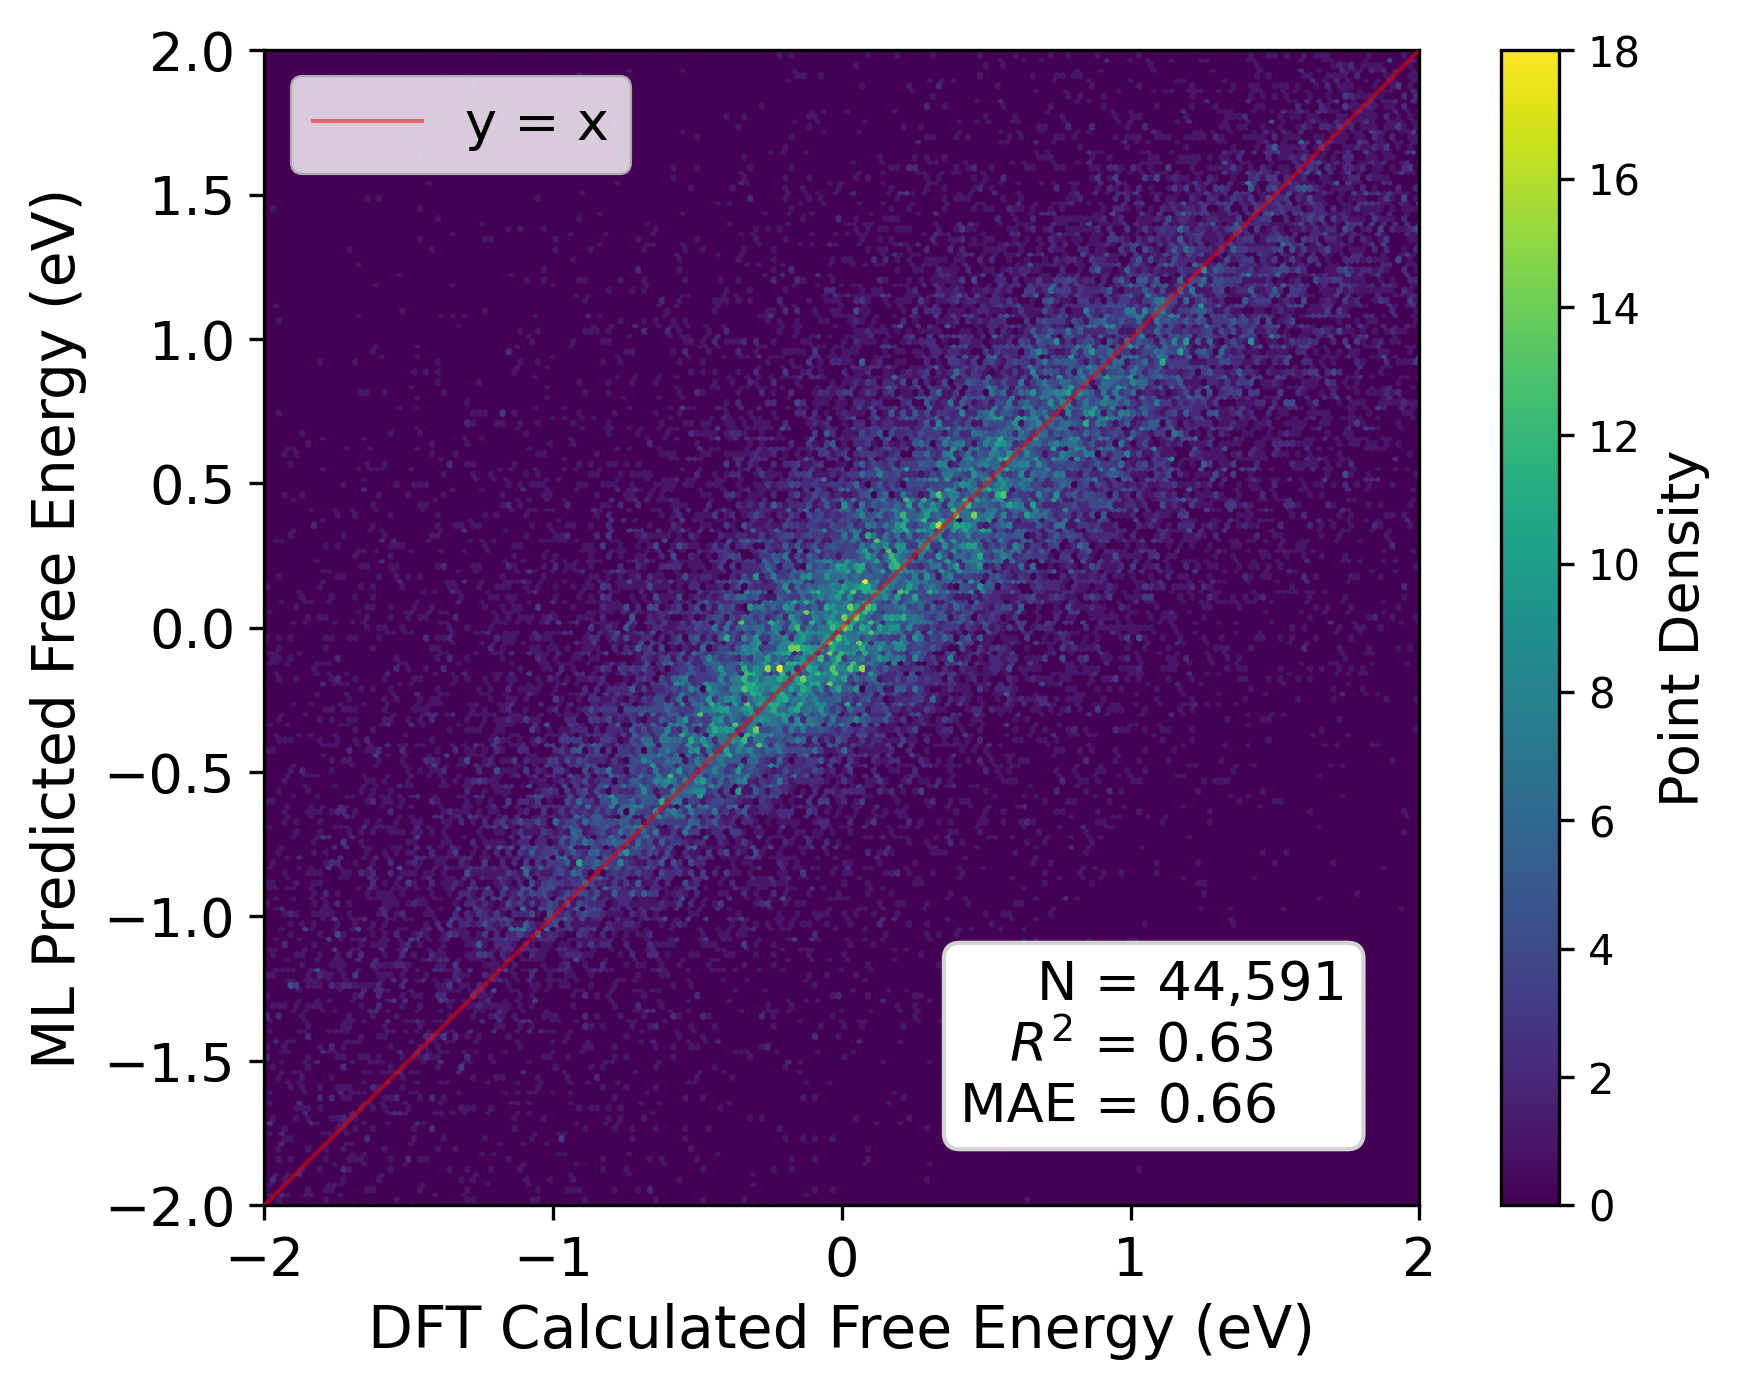

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pickle

with open('/mnt/z/pickles/intermediate_energies.pkl', 'rb') as f:
    E_intermediate_true, E_intermediate_pred = pickle.load(f)
E_intermediate_true = np.array(E_intermediate_true)
E_intermediate_pred = np.array(E_intermediate_pred)


# Create the figure and subplots
fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=300)
max_val = 2
hb = ax.hexbin(E_intermediate_true, E_intermediate_pred, gridsize=196, extent=(-max_val, max_val, -max_val, max_val), zorder=2, linewidths=0.3)

# Plot a y=x reference line
ax.plot([-max_val, max_val], [-max_val, max_val], 'red', alpha=0.5, lw=1, label='y = x', zorder=3)

ax.set_aspect('equal')
ax.set_xlim([-max_val, max_val])
ax.set_ylim([-max_val, max_val])
ax.set_xlabel('DFT Calculated Free Energy (eV)', fontsize=ax_font_size)
ax.set_ylabel('ML Predicted Free Energy (eV)', fontsize=ax_font_size)

# Optionally add text inside the plot with R and MAE
ax.text(max_val - 0.25, -max_val + 0.25, 
        f'N = {len(E_intermediate_true):,}\n$R^2$ = {r2_score(E_intermediate_true, E_intermediate_pred):.2f}     \nMAE = {np.mean(np.abs(E_intermediate_true - E_intermediate_pred)):.2f}    ', 
        fontsize=ax_font_size-1, 
        bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round'), 
        ha='right', va='bottom')

ax.legend(loc='upper left', fontsize=ax_font_size-1)
ax.tick_params(axis='both', which='major', labelsize=ax_font_size-1)

# Add a colorbar to indicate the density
cb = plt.colorbar(hb)
cb.set_label('Point Density', fontsize=ax_font_size-1)
plt.show()


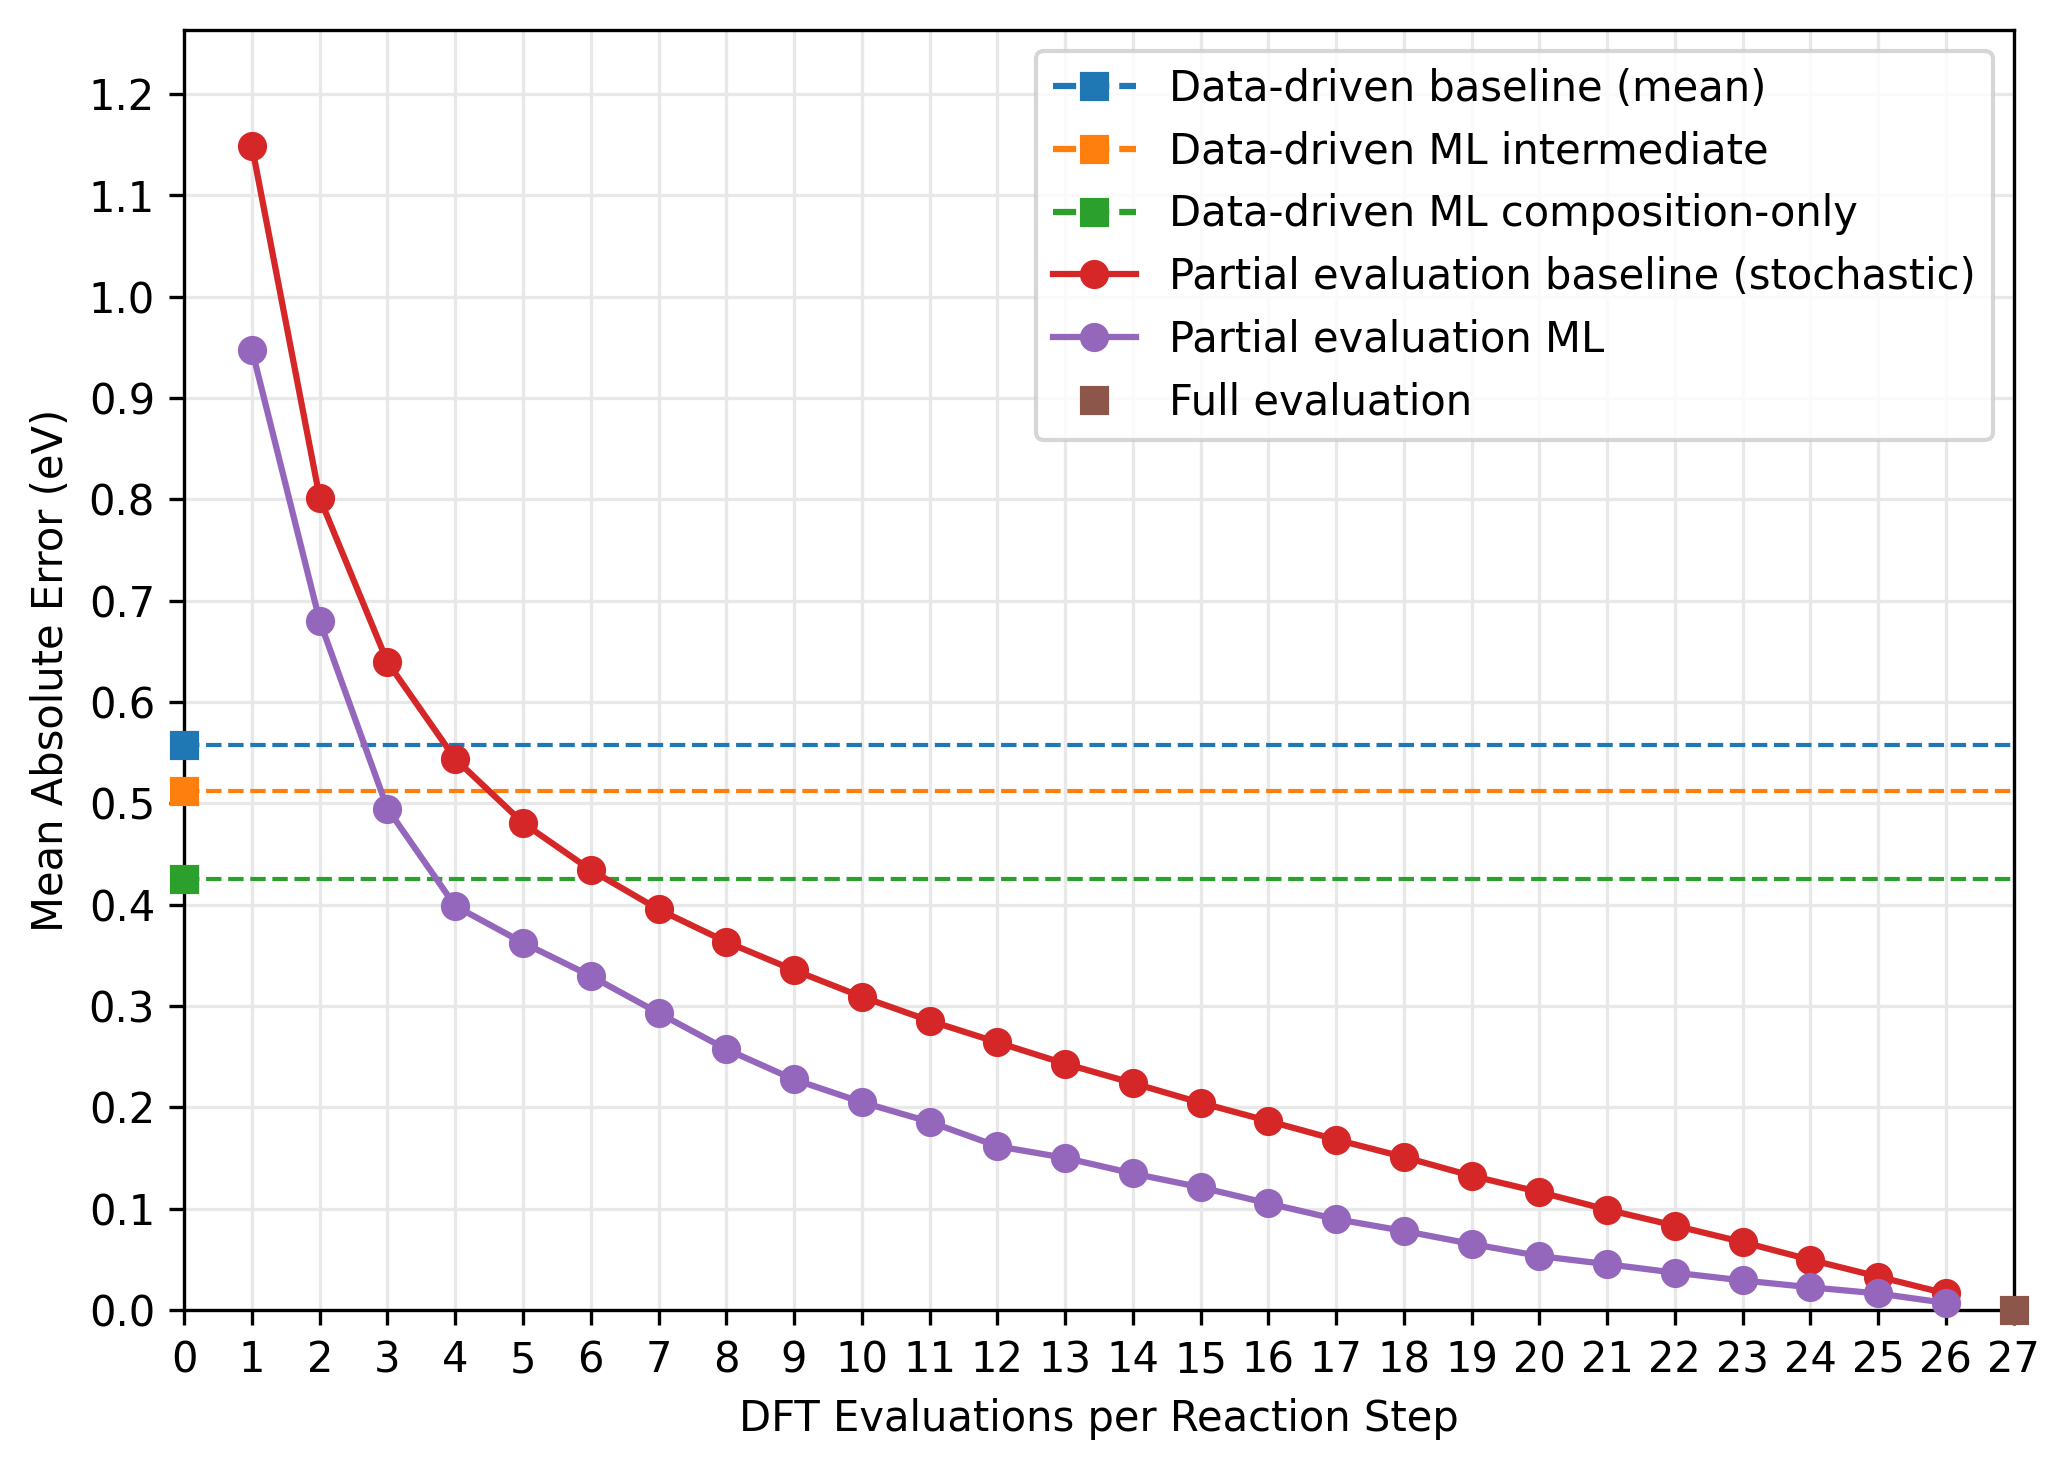

In [ ]:
import pickle
import matplotlib.pyplot as plt

_, _, _, _, ratio_mean_mae, ratio_R2, mean_mae = [ 0.030000, 0.200000, 0.99500, 0.42276, 0.42530, 0.20110, 0.55771]
reconstruction_mae = 0.51213

# 1) Load from pickle
with open('/mnt/z/pickles/min_k_predict_Von_Yenc_995.pkl', 'rb') as f:
    MAEs_predicted, MAEs_random = pickle.load(f)
MAEs_predicted = MAEs_predicted[:-1]
MAEs_random = MAEs_random[:-1]

with open('/mnt/z/pickles/min_k_predict_Von_Yenc_995.pkl', 'rb') as f:
    MAEs_Yenc, _ = pickle.load(f)
MAEs_Yenc = MAEs_Yenc[:-1]


# 2) Unpack data into separate lists
#    Each entry has (N_samples, Mean MAE)
Ns = [int(t[0]) for t in MAEs_predicted] 
MAE_mean_pred = [t[1] for t in MAEs_predicted]
MAE_mean_rand = [t[1] for t in MAEs_random]
MAE_mean_Yenc = [t[1] for t in MAEs_Yenc]

# 3) Plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 5), dpi=300)

ax.set_xlabel('DFT Evaluations per Reaction Step')
ax.set_ylabel('Mean Absolute Error (eV)')

ax.set_xticks(range(0, max(Ns) + 2))
ax.set_yticks([0.1 * x for x in range(0, 13)])

ax.plot([0], [mean_mae], '--s', label='Data-driven baseline (mean)', zorder=10, clip_on=False)
ax.hlines(y=mean_mae, linestyle='--', xmin=0, xmax=max(Ns) +1, linewidth=1, color=plt.gca().lines[-1].get_color(), zorder=10)

ax.plot([0], [reconstruction_mae], '--s', label='Data-driven ML intermediate', zorder=10, clip_on=False)
ax.hlines(y=reconstruction_mae, linestyle='--', xmin=0, xmax=max(Ns) + 1, linewidth=1, color=plt.gca().lines[-1].get_color(), zorder=10)

ax.plot([0], [ratio_mean_mae], '--s', label='Data-driven ML composition-only', zorder=10, clip_on=False)
ax.hlines(y=ratio_mean_mae, linestyle='--', xmin=0, xmax=max(Ns) + 1, linewidth=1, color=plt.gca().lines[-1].get_color(), zorder=10)

ax.plot(Ns, MAE_mean_rand, '-o', label='Partial evaluation baseline (stochastic)', zorder=10, clip_on=False)
# ax.plot(Ns, MAE_mean_pred, '-o', label='Full Dataset Partial Evaluation', zorder=10, clip_on=False)
ax.plot(Ns, MAE_mean_Yenc, '-o', label='Partial evaluation ML', zorder=10, clip_on=False)

ax.plot([max(Ns) + 1], [0], 's',  label='Full evaluation', zorder=10, clip_on=False)
ax.set_xlim(0, max(Ns) + 1)
ax.set_ylim(0, max(max(MAE_mean_pred), max(MAE_mean_rand), mean_mae, ratio_mean_mae) * 1.1)

ax.grid(color='#E8E8E8')
ax.legend()
plt.tight_layout()
plt.show()


Onset potential -0.2492529303412275 for GaMn2O4 is 0.866 V
Onset potential -0.24928952533740767 for (ZnFe)CoMnO4 is 0.897 V
Onset potential -0.24901778915202444 for CoMnFeO4 is 0.901 V
Onset potential -0.24963977005347593 for CoMnGaO4 is 0.903 V


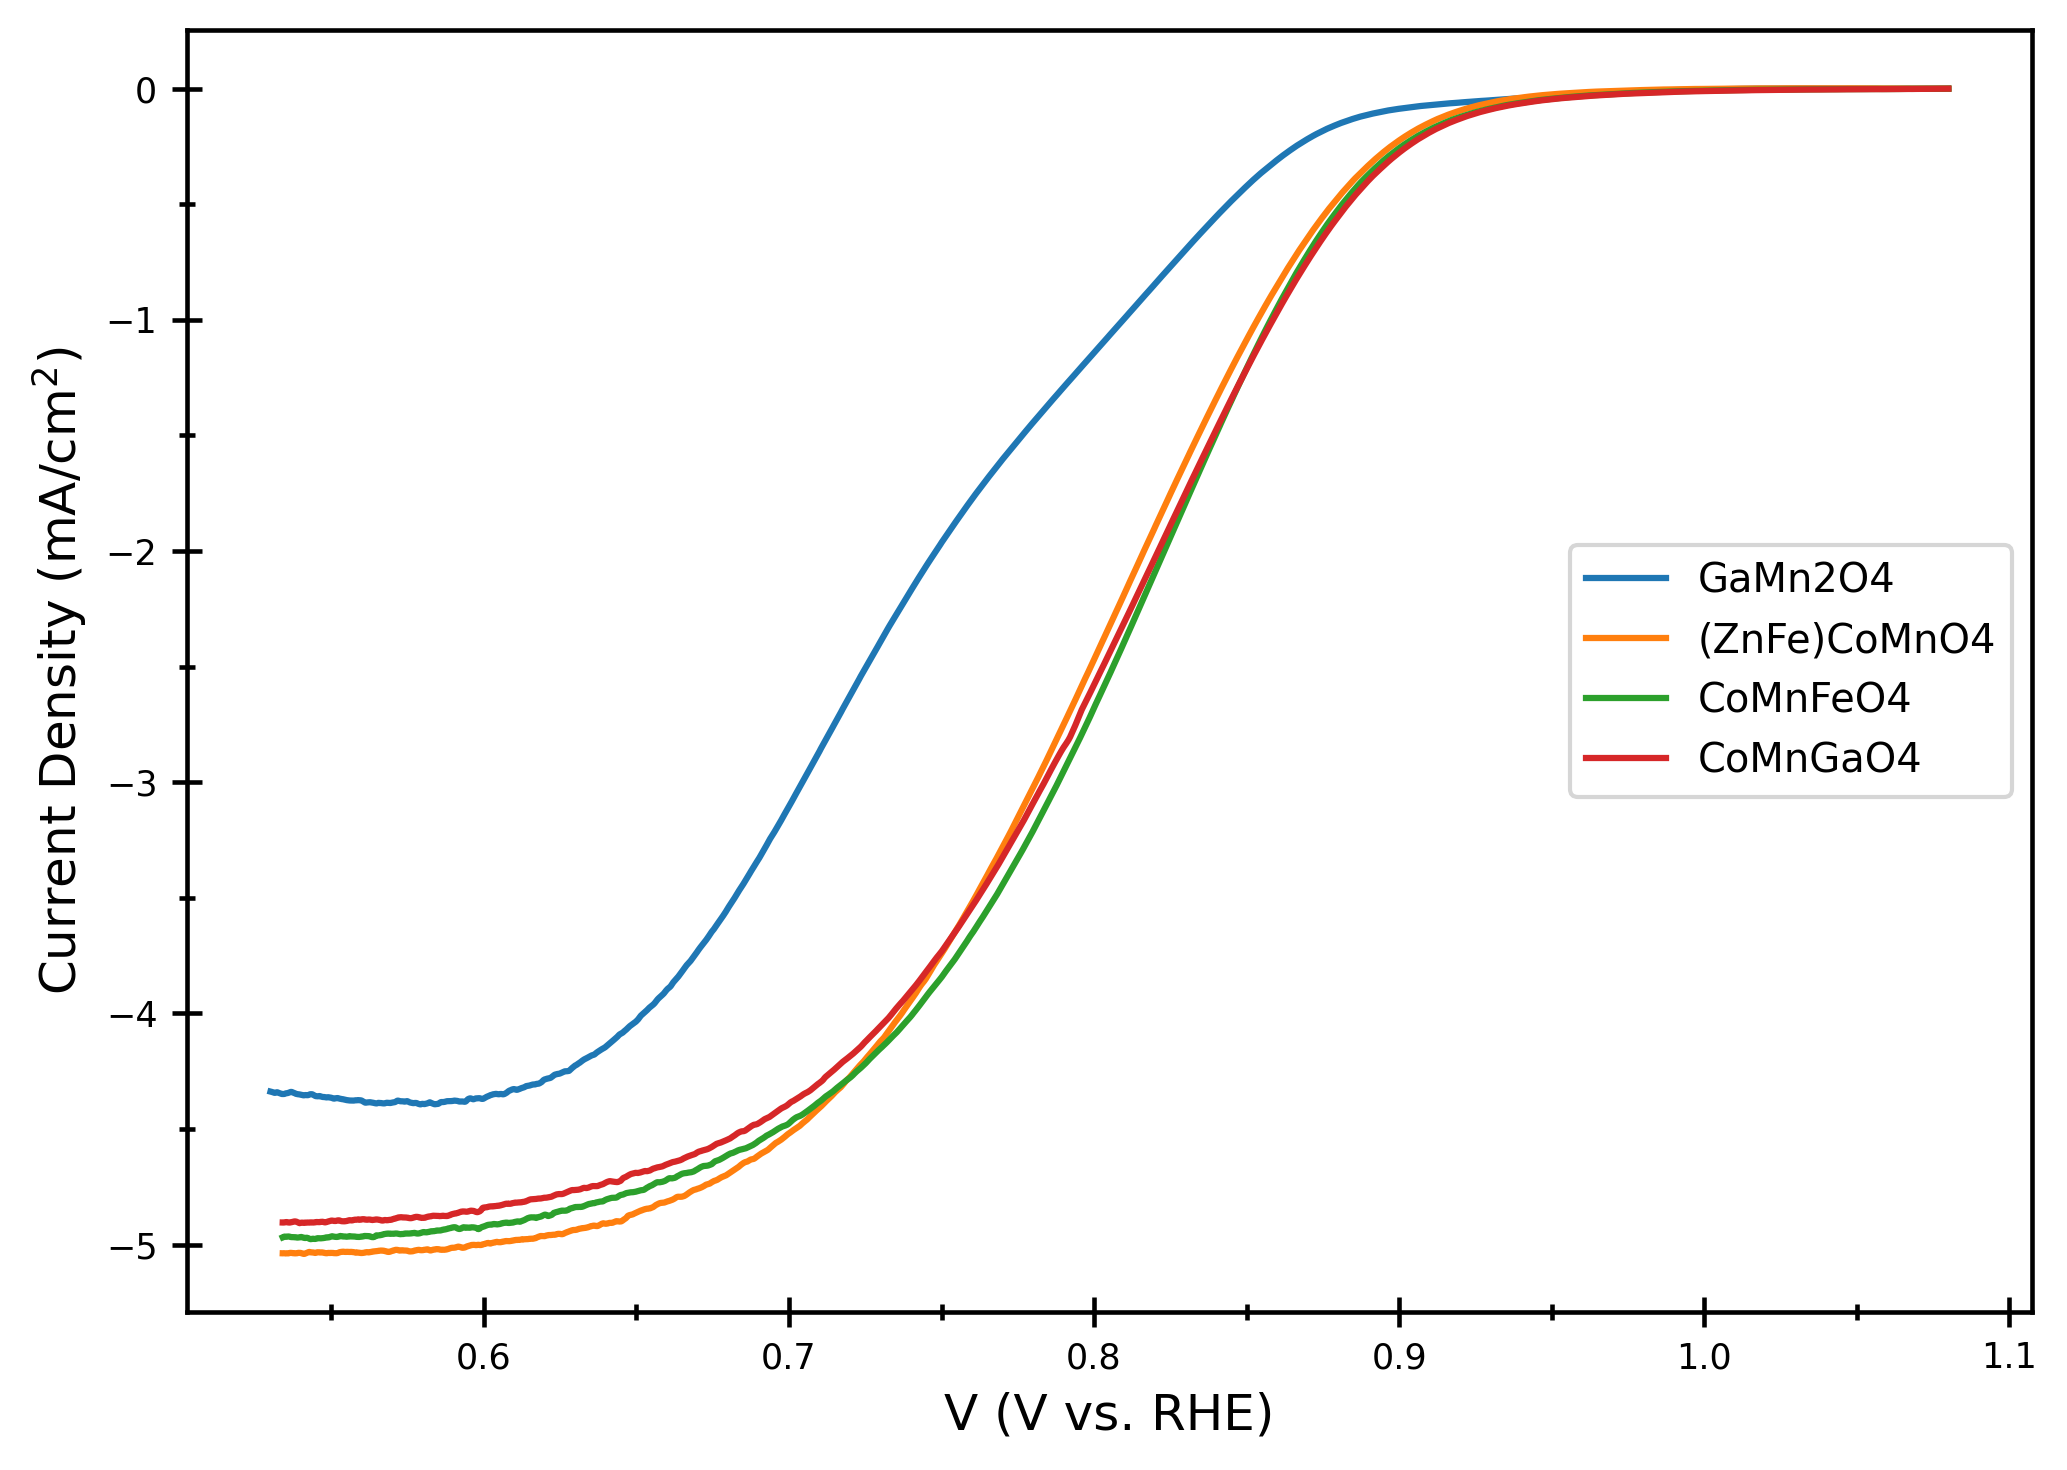

In [14]:
# type: ignore
import IPython
if 'IPython.extensions.autoreload' not in IPython.get_ipython().extension_manager.loaded:
    %load_ext autoreload
    %autoreload 2

import os
import utils
import plotters
import matplotlib.pyplot as plt
dpi=300
figsize=(7, 5)
fontsize=12
base_folder = '/mnt/c/Users/colin/Dropbox/School/PhD Research/2025_spinel_paper/data'
cv_data_filename = 'cv.xlsx'
cv_path = os.path.join(base_folder, cv_data_filename)
image_path = os.path.join(base_folder, 'cvplots.png')

df_dict = utils.dfs_from_spreadsheets(cv_path)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
for i, (sheet_name, df) in enumerate(df_dict.items()):
    slope = 0.65 if i == 0 else 0.5
    plotters.plot_cv_data({sheet_name: df}, ax, fontsize, slope, plot_corrected=False)

fig.tight_layout(w_pad=2)
plt.savefig(image_path, dpi=dpi, bbox_inches='tight')
plt.show()

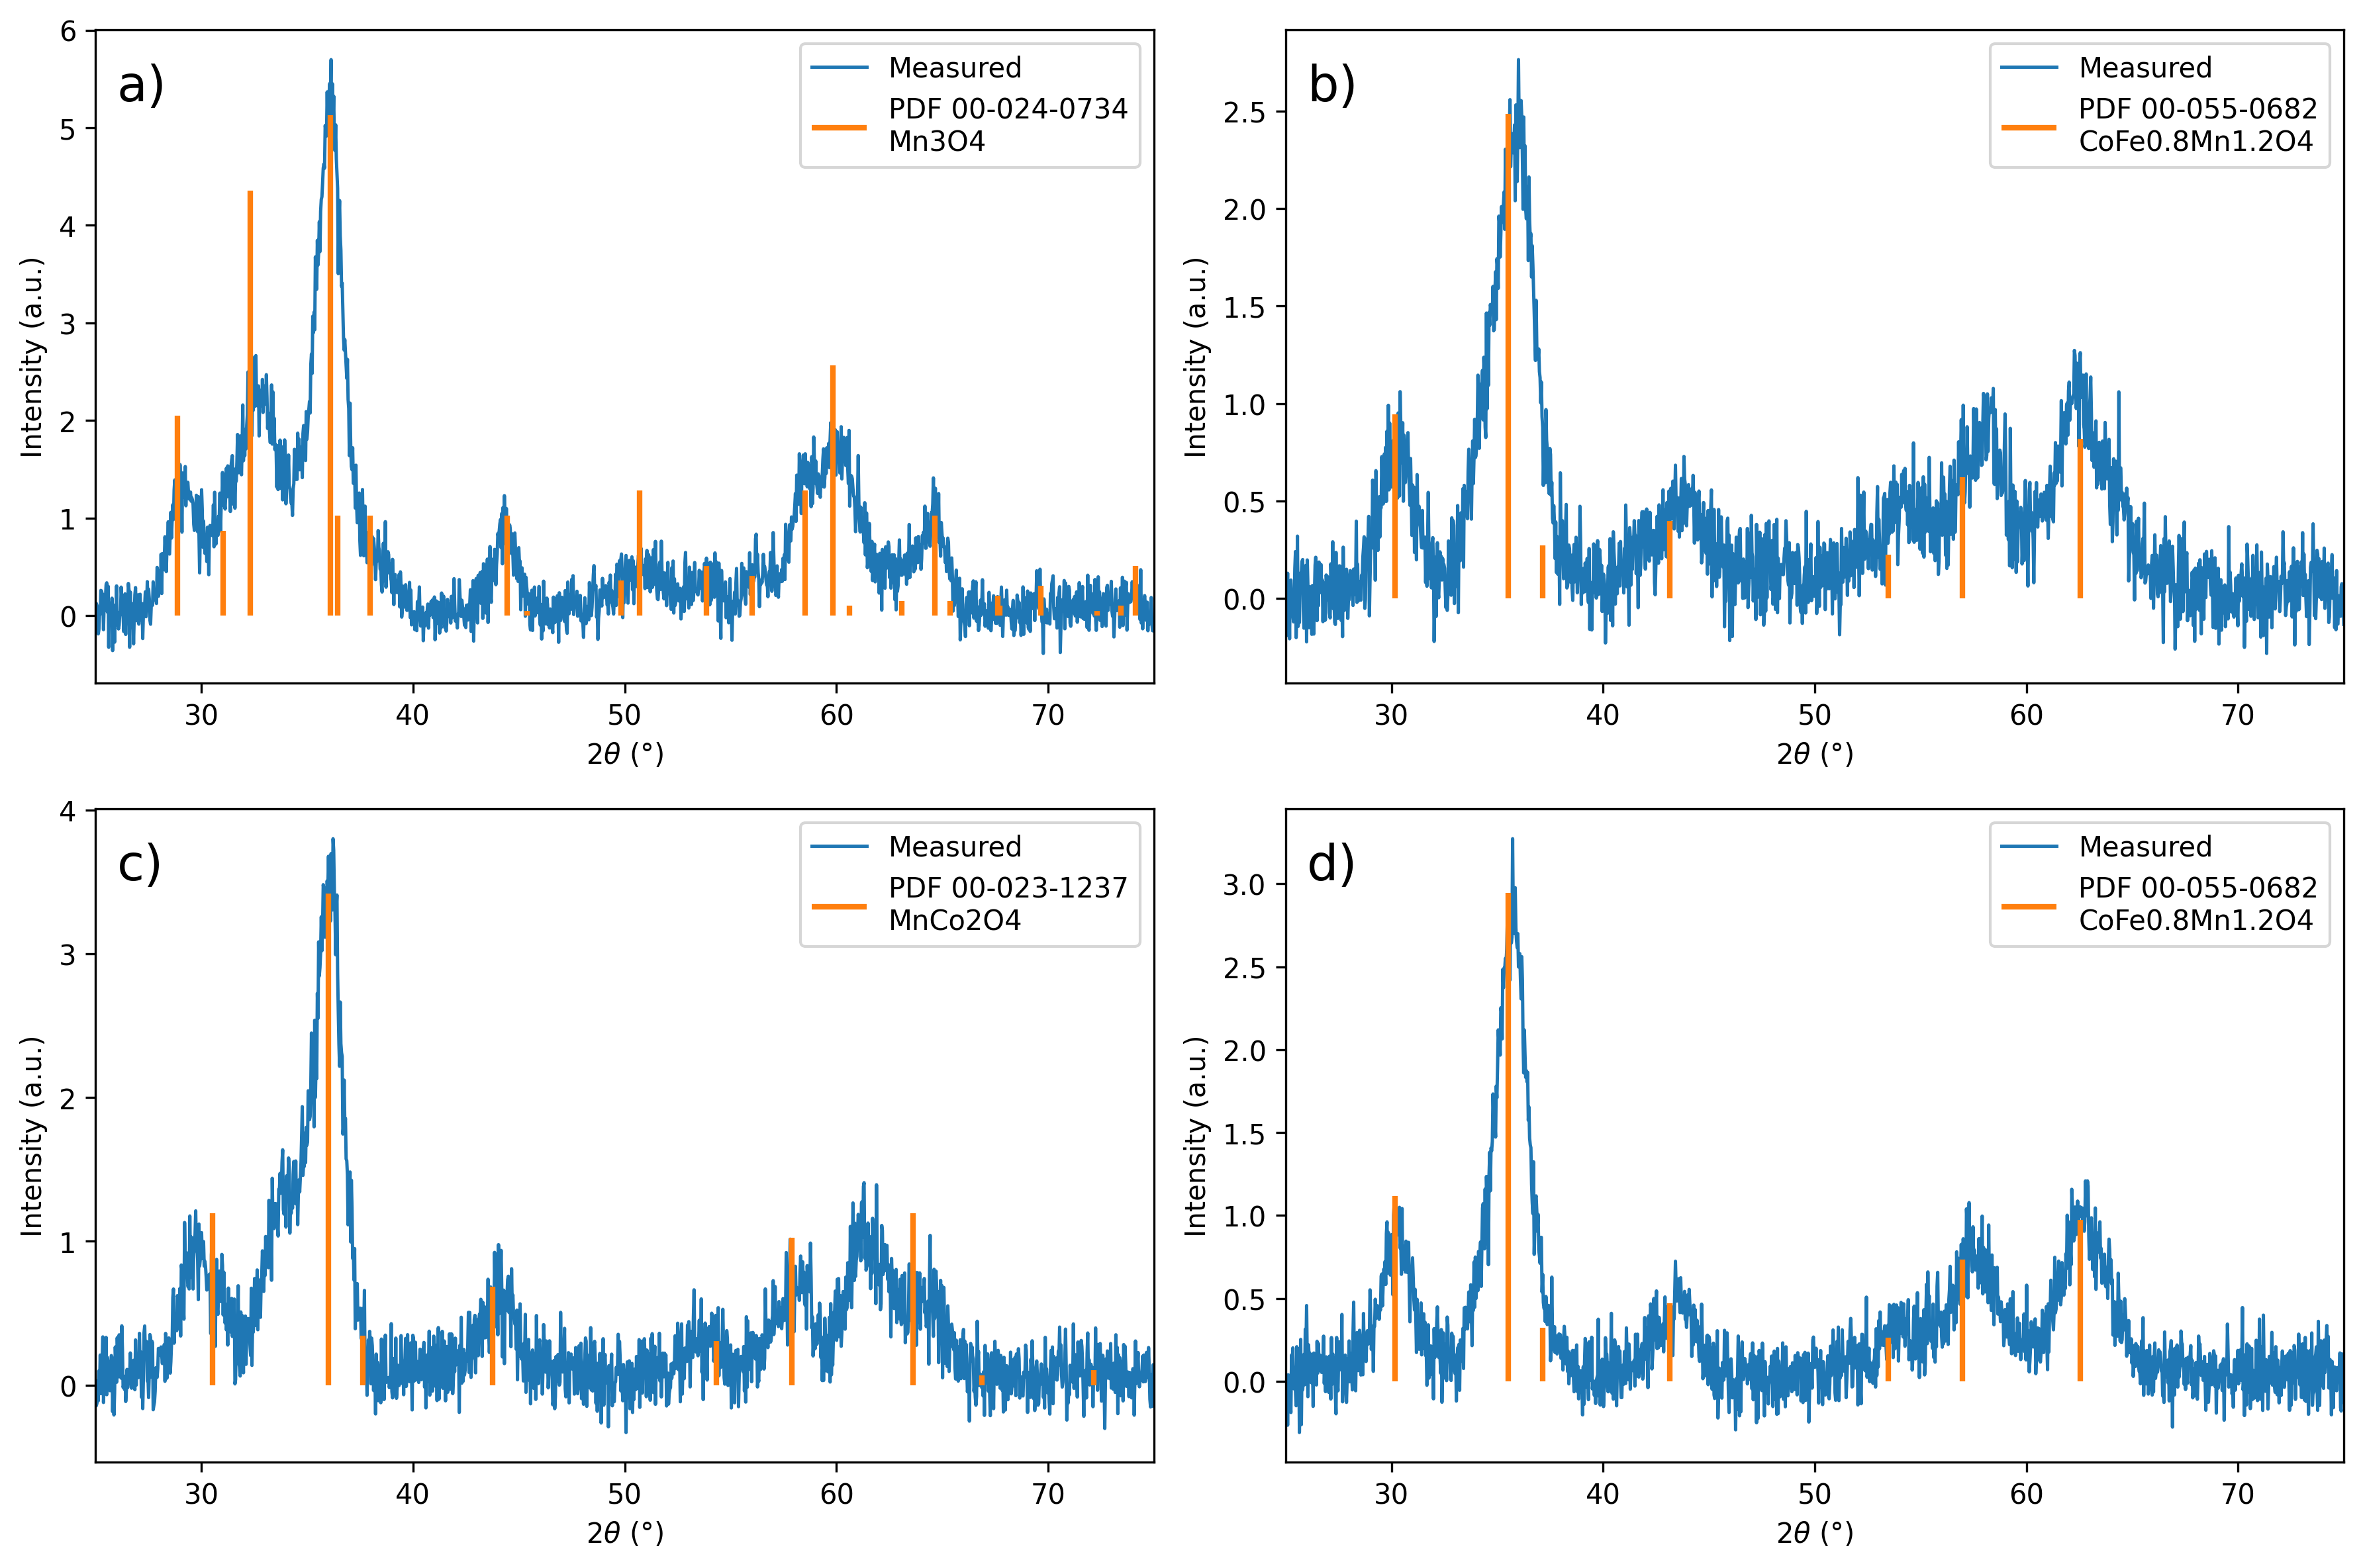

In [25]:
# 2×2 XRD overlay grid with lettered panels  ·  Python 3.12+

from __future__ import annotations

from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt


# ---------- helper functions ----------

def load_xy(path: str | Path, *, skip_header: int = 1) -> tuple[np.ndarray, np.ndarray]:
    """Return 2θ (deg) and intensity arrays from a two-column .xy file."""
    data: np.ndarray = np.loadtxt(path, skiprows=skip_header)
    return data[:, 0], data[:, 1]


def parse_pdf_sticks(xml_path: str | Path) -> tuple[np.ndarray, np.ndarray]:
    """Extract stick (theta, intensity) arrays from an ICDD PDF card XML file."""
    root = ET.parse(xml_path).getroot()
    thetas, intensities = [], []

    for series in root.findall(".//stick_series"):
        for stick in series.findall("intensity"):
            thetas.append(float(stick.find("theta").text))
            intensities.append(float(stick.find("intensity").text))

    return np.asarray(thetas), np.asarray(intensities)


def plot_overlay(
    ax: plt.Axes,
    xy_file: str | Path,
    pdf_file: str | Path,
    *,
    stick_scale: float = 0.90,
) -> None:
    """Plot measured trace + scaled stick pattern on the supplied axis."""
    θ_meas, I_meas = load_xy(Path(f'/mnt/c/Users/colin/Dropbox/School/PhD Research/2025_spinel_paper/022225/{xy_file}'))
    θ_ref, I_ref = parse_pdf_sticks(Path(f'/mnt/c/Users/colin/Dropbox/School/PhD Research/2025_spinel_paper/xrd references Cu K alpha/PDF Card - {pdf_file}'))

    I_ref_scaled = I_ref * (I_meas.max() * stick_scale / I_ref.max())

    ax.plot(θ_meas, I_meas, lw=1.2, label="Measured")
    for t, i in zip(θ_ref, I_ref_scaled):
        ax.vlines(t, 0, i, lw=2, color="tab:orange")

    ax.set_xlim(25, 75)
    ax.set(xlabel=r"2$\theta$ (°)", ylabel="Intensity (a.u.)")
    ax.legend(["Measured", f"PDF {pdf_file[:11]}\n{pdf_file[12:-4]}"], loc="upper right")


# ---------- file list (EDIT THESE) ----------

file_pairs: list[tuple[str, str]] = [
    ("JLR-7-043_1.4sec_bg_subtracted.xy", "00-024-0734 Mn3O4.xml"),
    ("JLR-7-044_1.4sec_bg_subtracted.xy", "00-055-0682 CoFe0.8Mn1.2O4.xml"),
    ("JLR-7-045_1.4sec_bg_subtracted.xy", "00-023-1237-MnCo2O4.xml"),
    ("JLR-7-053_1.4sec_bg_subtracted.xy", "00-055-0682 CoFe0.8Mn1.2O4.xml"),
]

# ---------- plotting ----------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False, dpi=300)
axes_flat = axes.flatten()

for idx, (ax, (xy, pdf)) in enumerate(zip(axes_flat, file_pairs)):
    plot_overlay(ax, xy, pdf)

    # panel label: a), b), c), d)
    label = f"{chr(97 + idx)})"          # chr(97) == 'a'
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,
        fontsize="18",
        va="top",
        ha="left",
    )

plt.tight_layout()
plt.show()
